# 91250 - Deep Learning 
By: Toh Kok Soon (Matricola: 1900146040)

This notebook:
1. is written and intended to be ran locally. It could possibly be adapted to run on Google Colab but is not tested.
2. follows Python PEP 8 styles guidelines but with some additional flexibility
3. only contain the necessary parts, additional code and experimentation is available on Github Repo (https://github.com/IAmGreyBunny/91250-Deep-Learning) 

## 0. Import and Configs

In [1]:
# File Operations
import gdown
import os
from pathlib import Path

# Math & Visualization
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau
from torchinfo import summary

# Misc
from sklearn.model_selection import train_test_split
import copy
import pprint as pp
import time
import pickle

In [2]:
# Set Device to GPU if available
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"CUDA Available: {torch.cuda.is_available()}")

CUDA Available: True


In [3]:
# Fixing seed to reduce randomness, for better comparisons
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [4]:
# File Paths
TRAIN_FILE_ID = "1xyggntfZ2-6BTAagxJm-tFKDXerTAs8c"
TEST_FILE_ID  = "1VozRpr3dlVpA17BL-7ALCaOXa2vCe64J"

DATA_FOLDER = "data"
TRAIN_PATH = os.path.join(DATA_FOLDER,"chess_error_detection_train.csv")
TEST_PATH  = os.path.join(DATA_FOLDER,"chess_error_detection_test.csv")

MODEL_FOLDER = "model"
os.makedirs(MODEL_FOLDER, exist_ok=True)
BEST_ENCODER_PATH = os.path.join(MODEL_FOLDER,"best_encoder.pt")
BEST_MODEL_PATH = os.path.join(MODEL_FOLDER,"best_model.pt")

VOCABULARY_MAPPING_PATH = os.path.join(MODEL_FOLDER,"vocabulary_mapping.pkl")

if not os.path.exists(TRAIN_PATH):
    gdown.download(id=TRAIN_FILE_ID, output=TRAIN_PATH, quiet=False)

if not os.path.exists(TEST_PATH):
    gdown.download(id=TEST_FILE_ID, output=TEST_PATH, quiet=False)

In [5]:
RUN_PRETRAINING = False
RUN_TRAINING = False
LOAD_VOCABULARY_MAPPING = True # Always keep this as True unless no vocabulary mapping have been done, or a new one is necessary

## 1. Data
Because we are only given train and test set, we should split the train into train and validation, so we don't use test set to make decision during training. Below code show the split ratio (80:20)

In [6]:
train_df = pd.read_csv(TRAIN_PATH)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["error_position"]
)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape: ", test_df.shape)

display(train_df.head())

Train shape: (320000, 3)
Validation shape: (80000, 3)
Test shape:  (50000, 3)


,sequence,error_position,correct_move
91975,g3 d5 e4 c4 Nf3 Bg4 Bg2 e5 O-O Bd6 d3 Nf6 c4 d...,4,d4
252136,d4 e6 c4 d5 cxd5 Qxd5 e3 c5 Nc3 Qh5 Be2 Qg6 dx...,2,Nf6
264691,e4 e6 Qf3 c5 exd5 exd5 Nc3 Nf6 h3 Bb4 g4 O-O g...,4,d5
130957,e4 e5 Nf3 d6 Nf3 exd4 Nxd4 d5 exd5 Qxd5 Nc3 Qe...,5,d4
240371,e4 g6 d4 Bg7 Nc3 dxe4 Nge2 c6 h3 Qc7 g4 e5 Bg2...,6,d6


### Class distribution
From the distribution below, we can see the dataset is quite balanced in terms of classes so from random guessing, we should be able to get ~10% correct prediction, this serves as a baseline for any model we develop

In [7]:
train_distribution = train_df["error_position"].value_counts(normalize=True).sort_index()
test_distribution = test_df["error_position"].value_counts(normalize=True).sort_index()

distribution = pd.DataFrame({
    "train": train_distribution,
    "test": test_distribution,
})

display(distribution)

,train,test
error_position,,
1,0.099728,0.09972
2,0.100694,0.10070
3,0.100166,0.10018
4,0.099256,0.09926
5,0.100719,0.10072
6,0.099966,0.09996
7,0.099625,0.09962
8,0.099903,0.09990
9,0.099747,0.09974


## 2. Tokenization
For tokenizing, we identify all unique moves in the training distribution, then add the `<PAD>` and `<UNK>`, our dataset is quite clean so the `<PAD>` token is not really necessary but we will use it for masking later on. `<UNK>` is necessary as some moves are not seen in the training distribution but appear in other distribution, therefore a token is needed to represent these moves.

Here, we calculate some basic stats for the tokens, the unique unseen moves and unknown count exist but is low enough that it should not affect the performance of the model. Adding these into the vocabulary would be unecessary as there is no training data on it anyway.

In [8]:
unique_moves = set()
unique_moves.add("<PAD>")
unique_moves.add("<UNK>")

for game in train_df["sequence"]:
    for move in game.split():
        unique_moves.add(move)

In [9]:
train_vocab = unique_moves

test_moves = []

for game in test_df["sequence"]:
    test_moves.extend(game.split())

print("Unique moves in training distribution:", len(train_vocab))

unknown_unique = set(test_moves) - train_vocab
print("Unique unseen moves:", len(unknown_unique))

unknown_count = sum(move not in train_vocab for move in test_moves)
print("Unknown count:", unknown_count)
print("Unknown rate:", unknown_count / len(test_moves))

Unique moves in training distribution: 3597
Unique unseen moves: 99
Unknown count: 105
Unknown rate: 5.25e-05


### Integer-coding
We then encode each of these unique moves to an integer, with `<PAD>` and `<UNK>` explicitly coded. It is important to do so as we will need to identify `<PAD>` token during masking.

In [10]:
if LOAD_VOCABULARY_MAPPING:
    if os.path.exists(VOCABULARY_MAPPING_PATH):
        with open(VOCABULARY_MAPPING_PATH, "rb") as f:
            vocab_to_id = pickle.load(f)
    else:
        print("Vocabulary mapping not found")
else:
    vocab_to_id = {
        "<PAD>": 0,
        "<UNK>": 1
    }
    
    for move in unique_moves:
        if move not in vocab_to_id:
            vocab_to_id[move] = len(vocab_to_id)

    # Save new mapping
    with open(VOCABULARY_MAPPING_PATH, "wb") as f:
        pickle.dump(vocab_to_id, f)
    print("Created and saved vocabulary mapping.")
    
VOCAB_SIZE = len(vocab_to_id)
print("Vocabulary size:", VOCAB_SIZE)

Vocabulary size: 3597


In [11]:
id_to_vocab = {
    idx: move
    for move, idx in vocab_to_id.items()
}

In [12]:
def encode_sequence(sequence, vocab_to_id):
    return [
        vocab_to_id.get(move, vocab_to_id["<UNK>"])
        for move in sequence.split()
    ]

In [13]:
sequence = train_df["sequence"].iloc[0]

encoded = encode_sequence(sequence, vocab_to_id)

print("----- Example -----")
print(sequence)
print()
print(encoded)
print()
print(f"Length: {len(encoded)}")

----- Example -----
g3 d5 e4 c4 Nf3 Bg4 Bg2 e5 O-O Bd6 d3 Nf6 c4 dxc3 Nxc3 c6 Bg5 O-O Qd2 Nbd7 Bxf6 Qxf6 Nh4 g5 Nf5 Bb4 a3 Bxc3 Qxc3 Nb6 Ne3 Bf3 Bxf3 Qxf3 Ng2 Qf6 f4 gxf4 Nxf4 Na4

[2979, 2238, 1164, 1540, 154, 682, 1483, 2163, 3547, 1931, 3122, 942, 1540, 411, 894, 322, 2393, 3547, 1687, 2926, 2856, 2492, 2191, 1544, 1256, 636, 3252, 1301, 2397, 3204, 858, 59, 3521, 1769, 3406, 327, 1056, 2940, 3184, 1126]

Length: 40


In [14]:
train_encoded = [
    encode_sequence(seq, vocab_to_id)
    for seq in train_df["sequence"]
]

val_encoded = [
    encode_sequence(seq, vocab_to_id)
    for seq in val_df["sequence"]
]

test_encoded = [
    encode_sequence(seq, vocab_to_id)
    for seq in test_df["sequence"]
]

### Creating Dataloaders

In [15]:
# Shift labels for ease of work internally
train_labels = train_df["error_position"].to_numpy() - 1
val_labels = val_df["error_position"].to_numpy() - 1
test_labels = test_df["error_position"].to_numpy() - 1

In [16]:
x_train = torch.tensor(train_encoded, dtype=torch.long)
y_train = torch.tensor(train_labels, dtype=torch.long)

x_val = torch.tensor(val_encoded, dtype=torch.long)
y_val = torch.tensor(val_labels, dtype=torch.long)

x_test = torch.tensor(test_encoded, dtype=torch.long)
y_test = torch.tensor(test_labels, dtype=torch.long)

In [17]:
train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

## 3. Model Definitions
Initially, we trained a single transformer classification model to get a baseline performance that we can then compare to. The basline transformer model had a performance of 91.75% on an embedding dimension of 128, and 92.5% with embedding dimension of 256. We then try masked autoencoding to help the model learn better representation in hope of improving performance for downstream task(i.e. anomaly detection through classification). This is done by first passing the inputs through the transformer encoder, masking a few token, then getting the model to attempt at reconstructing the sequence. Therefore, the entire process can be broken down into two parts (i.e. pretraining and training).

For the pretraining phase, we would use the `ChessAutoencoder` which contains two subparts `ChessEncoder` and `ChessReconstructor`. 

For the final model, we would reuse the `ChessEncoder` from the `ChessAutoencoder` and discared the `ChessReconstructor`. The final model is `ChessClassifier` which includes the `ChessEncoder` obtained from pretraining along with a classification head.

### Encoder

In [18]:
class ChessEncoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=128,
        nhead=4,
        num_layers=3,
        dim_feedforward=256,
        dropout=0.1,
        max_len=40
    ):
        super().__init__()
        
        self.d_model = d_model
        self.max_len = max_len

        self.token_embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.position_embedding = nn.Embedding(
            max_len,
            d_model
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

    def forward(self, x):
        batch_size, seq_len = x.shape

        positions = torch.arange(
            seq_len,
            device=x.device
        )

        token_embeddings = self.token_embedding(x)
        position_embeddings = self.position_embedding(positions)

        x = token_embeddings + position_embeddings

        x = self.transformer(x)
        return x

### Reconstructor 

In [19]:
class ChessReconstructor(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.1
    ):
        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer ,
            num_layers=num_layers
        )

        self.output_projection = nn.Linear(
            d_model,
            vocab_size
        )

    def forward(self, x):
        x = self.transformer(x)
        logits = self.output_projection(x)
        return logits

### Autoencoder
The masking is only done to the first 10 token in the sequence because these are the token that may have the anomalous move, so we should focus on these. 

It is important to note that the `mask_ratio` have to be at least 0.2 since one of the masked token have to be the corrupted move from the original sequence, a 0.1 `mask_ratio` would result in no loss as the corrupted token is not taken into account during loss calculation

In [20]:
class ChessAutoencoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=128,
        nhead=4,
        encoder_layers=3,
        reconstructor_layers=2,
        dim_feedforward=256,
        dropout=0.1,
        max_len=40,
        candidate_len=10,
        mask_ratio=0.3,
        pad_token_id=0
    ):
        super().__init__()

        self.candidate_len = candidate_len
        self.mask_ratio = mask_ratio
        self.pad_token_id = pad_token_id

        self.encoder = ChessEncoder(
            vocab_size=vocab_size,
            d_model=d_model,
            nhead=nhead,
            num_layers=encoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            max_len=max_len
        )

        self.reconstructor = ChessReconstructor(
            vocab_size=vocab_size,
            d_model=d_model,
            nhead=nhead,
            num_layers=reconstructor_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout
        )

    # Create mask, always mask corrupted position and additional positions to make up for the masking ratio, 
    # Only the first 10 positions can be masked 
    def create_mask(
        self,
        batch_size,
        corrupted_positions,
        device
    ):
        # Number of positions to mask
        num_masked = max(
            1,
            round(self.candidate_len * self.mask_ratio)
        )

        mask = torch.zeros(
            batch_size,
            self.candidate_len,
            dtype=torch.bool,
            device=device
        )

        batch_indices = torch.arange(
            batch_size,
            device=device
        )

        # Always mask the known corrupted position
        mask[
            batch_indices,
            corrupted_positions
        ] = True

        # Number of additional positions
        additional_needed = num_masked - 1
        if additional_needed > 0:
            for i in range(batch_size):
            
                # Positions not already masked
                available = torch.where(
                    ~mask[i]
                )[0]

                # Randomly choose additional positions
                selected = available[
                    torch.randperm(
                        len(available),
                        device=device
                    )[:additional_needed]
                ]

                mask[i, selected] = True

        return mask

    def forward(self, x, corrupted_positions):
        mask = self.create_mask(
            batch_size=x.size(0),
            corrupted_positions=corrupted_positions,
            device=x.device
        )

        # Expand the mask to the entire move sequence
        full_mask = torch.zeros(
            x.size(0),
            x.size(1),
            dtype=torch.bool,
            device=x.device
        )
        full_mask[:, :self.candidate_len] = mask

        masked_x = x.clone()
        masked_x[full_mask] = self.pad_token_id

        encoded = self.encoder(masked_x)
        logits = self.reconstructor(encoded)

        return logits, full_mask

### Classifier

In [21]:
class ChessClassifier(nn.Module):
    def __init__(
        self,
        encoder,
        d_model=128,
        candidate_len=10
    ):
        super().__init__()

        self.encoder = encoder
        self.candidate_len = candidate_len

        self.classifier = nn.Linear(d_model,1)

    def forward(self, x):
        encoded = self.encoder(x)

        # Only the first 10 positions are candidates
        encoded = encoded[:, :self.candidate_len, :]

        # Predict one score for each candidate position
        logits = self.classifier(encoded)
        logits = logits.squeeze(-1)

        return logits

## 4. Pre-Training and Training

### Pre-training

In [22]:
autoencoder = ChessAutoencoder(vocab_size=VOCAB_SIZE)

In [23]:
autoencoder = autoencoder.to(DEVICE)

#### Reconstruction_loss
We needed a custom loss function because there are unique logics involved that is not covered by the standard loss functions given.

For our use case we need to know where the masked tokens are and also the corrupted move from the original sequence. While in an ideal scenario, we would have clean moves sequences to calculate the reconstruction loss, this is not possible due to the project explicitly mentioning not to use the correct prediction for input. Our solution is then to always mask the corrupted move along with others but omitting it from loss calculation to avoid the model learning the wrong things, which would introduce unnecessary noise.

Furthermore, we only calculate the loss on masked tokens because the unmasked tokens would remain the same and would just introduce unnecessary overhead if we were to process all of them.

In [24]:
def reconstruction_loss(
    logits,
    targets,
    mask,
    corrupted_positions
):
    
    batch_size = targets.size(0)

    # Create mask for corrupted positions
    corrupted_mask = torch.zeros_like(mask)

    batch_indices = torch.arange(
        batch_size,
        device=targets.device
    )

    corrupted_mask[
        batch_indices,
        corrupted_positions
    ] = True

    # Only calculate loss on masked positions that are NOT corrupted
    loss_mask = mask & ~corrupted_mask

    # Select predictions and targets
    selected_logits = logits[loss_mask]
    selected_targets = targets[loss_mask]

    loss = F.cross_entropy(
        selected_logits,
        selected_targets
    )

    return loss

#### Pretraining loop
Here we define the train function, as well as the optimizer and scheduler. For pre-training and also in training later on, we introduce early stopping so we don't have to manually decide the number of epochs to train for and a `ReduceLROnPlateau` scheduler in an attempt to converge better. The early stopping triggers is set with a patience of 5, and the scheduler is set with a patience of 3. For the scheduler used during pre-training, we try to minimize the validation loss.

In [25]:
if(RUN_PRETRAINING):
    optimizer = torch.optim.AdamW(
        autoencoder.parameters(),
        lr=1e-4,
        weight_decay=1e-4
    )
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.1,
        patience=3,
        min_lr=1e-6
    )

In [26]:
def train_autoencoder(model, loader, optimizer, DEVICE):
    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    for x, corrupted_positions in loader:

        x = x.to(DEVICE)
        corrupted_positions = corrupted_positions.to(DEVICE)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        logits, mask = model(x,corrupted_positions)

        # Reconstruction loss
        loss = reconstruction_loss(logits,x,mask,corrupted_positions)

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        # Stats
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size

        # Identify positions used for loss
        corrupted_mask = torch.zeros_like(mask)

        batch_indices = torch.arange(
            batch_size,
            device=DEVICE
        )

        corrupted_mask[
            batch_indices,
            corrupted_positions
        ] = True

        loss_mask = mask & ~corrupted_mask

        # Predictions at the reconstruction positions
        predictions = logits.argmax(dim=-1)
        total_correct += (predictions[loss_mask] == x[loss_mask]).sum().item()
        total_samples += loss_mask.sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = (
        total_correct / total_samples
        if total_samples > 0
        else 0
    )

    return avg_loss, accuracy

In [27]:
def validate_autoencoder(
    model,
    loader,
    DEVICE
):

    model.eval()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():

        for x, corrupted_positions in loader:

            x = x.to(DEVICE)
            corrupted_positions = corrupted_positions.to(DEVICE)

            logits, mask = model(
                x,
                corrupted_positions
            )

            loss = reconstruction_loss(
                logits,
                x,
                mask,
                corrupted_positions
            )

            batch_size = x.size(0)

            total_loss += loss.item() * batch_size

            # Create mask for corrupted positions
            corrupted_mask = torch.zeros_like(mask)

            batch_indices = torch.arange(
                batch_size,
                device=DEVICE
            )

            corrupted_mask[
                batch_indices,
                corrupted_positions
            ] = True

            # Only evaluate the clean masked positions
            loss_mask = mask & ~corrupted_mask

            predictions = logits.argmax(dim=-1)

            total_correct += (
                predictions[loss_mask] == x[loss_mask]
            ).sum().item()

            total_samples += loss_mask.sum().item()

    avg_loss = total_loss / len(loader)

    accuracy = (
        total_correct / total_samples
        if total_samples > 0
        else 0
    )

    return avg_loss, accuracy

In [28]:
PATIENCE = 5
MAX_EPOCH = 100

# Train flags
best_val_loss = float('inf')
epochs_without_improvement = 0

# For plotting graph
train_loss_list = []
val_loss_list = []
epoch_times = []

In [29]:
if(RUN_PRETRAINING):
    for epoch in range(MAX_EPOCH):
    
        start_time = time.time()
    
        train_loss, train_acc = train_autoencoder(
            autoencoder,
            train_loader,
            optimizer,
            DEVICE
        )
    
        val_loss, val_acc = validate_autoencoder(
            autoencoder,
            val_loader,
            DEVICE
        )
    
        scheduler.step(val_loss)
    
        # Store loss list
        train_loss_list.append(train_loss)
        val_loss_list.append(val_loss)
    
        # Calculate epoch time
        epoch_time = time.time() - start_time
    
        # Track LR
        current_lr = optimizer.param_groups[0]["lr"]
    
        # Print logging statements
        print(
            f"Epoch {epoch + 1}/{MAX_EPOCH} "
            f"| Train Loss: {train_loss:.4f} "
            f"| Train Acc: {train_acc:.4f} "
            f"| Val Loss: {val_loss:.4f} "
            f"| Val Acc: {val_acc:.4f} "
            f"| LR: {current_lr:.6f} "
            f"| Time: {epoch_time:.2f}s"
        )
    
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
    
            # Save best encoder
            torch.save(
                autoencoder.encoder.state_dict(),
                BEST_ENCODER_PATH
            )
    
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                print("Early stopping triggered.")
                break

Epoch 1/100 | Train Loss: 160.0466 | Train Acc: 0.4582 | Val Loss: 109.4056 | Val Acc: 0.5937 | LR: 0.000100 | Time: 236.74s
Epoch 2/100 | Train Loss: 104.2412 | Train Acc: 0.6058 | Val Loss: 87.5597 | Val Acc: 0.6612 | LR: 0.000100 | Time: 234.20s
Epoch 3/100 | Train Loss: 88.6090 | Train Acc: 0.6526 | Val Loss: 76.1391 | Val Acc: 0.6945 | LR: 0.000100 | Time: 228.98s
Epoch 4/100 | Train Loss: 79.7919 | Train Acc: 0.6804 | Val Loss: 69.1570 | Val Acc: 0.7174 | LR: 0.000100 | Time: 230.20s
Epoch 5/100 | Train Loss: 73.3786 | Train Acc: 0.7004 | Val Loss: 64.0291 | Val Acc: 0.7352 | LR: 0.000100 | Time: 228.36s
Epoch 6/100 | Train Loss: 68.7617 | Train Acc: 0.7155 | Val Loss: 60.2271 | Val Acc: 0.7462 | LR: 0.000100 | Time: 228.87s
Epoch 7/100 | Train Loss: 65.2908 | Train Acc: 0.7267 | Val Loss: 57.0418 | Val Acc: 0.7584 | LR: 0.000100 | Time: 227.65s
Epoch 8/100 | Train Loss: 62.1533 | Train Acc: 0.7374 | Val Loss: 54.4554 | Val Acc: 0.7681 | LR: 0.000100 | Time: 227.63s
Epoch 9/100 |

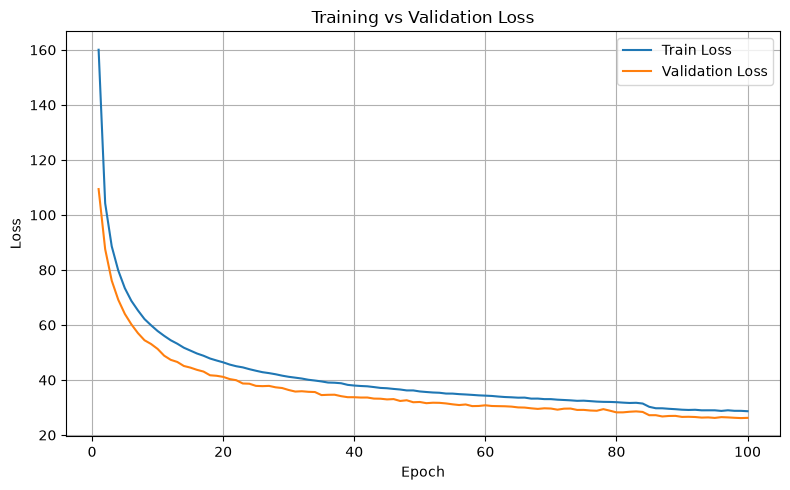

In [30]:
if(RUN_PRETRAINING):
    epochs = range(1, len(train_loss_list) + 1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss_list, label="Train Loss")
    plt.plot(epochs, val_loss_list, label="Validation Loss")
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [31]:
# Extract the encoder to be used later on
if(RUN_PRETRAINING):
    pretrained_encoder = autoencoder.encoder

### Training


In [32]:
# Deciding where to load the encoder from
if(RUN_PRETRAINING):
    classifier = ChessClassifier(
        encoder=pretrained_encoder,
        d_model=128,
        candidate_len=10
    ).to(DEVICE)
elif(RUN_TRAINING):
    encoder = ChessEncoder(
        vocab_size=VOCAB_SIZE,
        d_model=128,
        nhead=4,
        num_layers=3,
        dim_feedforward=256,
        dropout=0.1,
        max_len=40
    )
    
    encoder.load_state_dict(
        torch.load(BEST_ENCODER_PATH, map_location=DEVICE)
    )
    
    classifier = ChessClassifier(
        encoder=encoder,
        d_model=128,
        candidate_len=10
    )

In [33]:
def train_classifier(
    model,
    loader,
    optimizer,
    criterion,
    DEVICE
):

    model.train()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        # Reset gradient per batch
        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        # Backprop
        loss.backward()

        optimizer.step()

        # Stats
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        predictions = logits.argmax(dim=1)

        total_correct += (predictions == y).sum().item()
        total_samples += batch_size

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return avg_loss, accuracy

In [34]:
def validate_classifier(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            logits = model(x)

            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)

            predictions = logits.argmax(dim=1)

            total_correct += (
                predictions == y
            ).sum().item()

            total_samples += x.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return avg_loss, accuracy

#### Training Loop

Here, we repurpose the encoder obtained from pre-training for our downstream task of anomaly detection through classification. As mentioned before, we also use a patience and the `ReduceLROnPlateau` scheduler, however here we maximize accuracy instead of minimizing loss, this is because accuracy is the metric being evaluated for the project. The patience remain unchanged.

Since the downstream task is a simple classification problem, we do not need any custom loss function, we just use the standard cross entropy loss. 

In [35]:
if(RUN_TRAINING):
    criterion = nn.CrossEntropyLoss()
    
    optimizer = torch.optim.AdamW(
        classifier.parameters(),
        lr=1e-4,
        weight_decay=1e-4
    )
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.1,
        patience=3,
        min_lr=1e-6
    )

In [36]:
PATIENCE = 5
MAX_EPOCH = 100

# Train flags
best_val_acc = 0.0
epochs_without_improvement = 0

# For plotting graphs
train_acc_list = []
val_acc_list = []
epoch_times = []

In [37]:
if(RUN_TRAINING):
    for epoch in range(MAX_EPOCH):
        epoch_start_time = time.time()
    
        train_loss, train_acc = train_classifier(
            classifier,
            train_loader,
            optimizer,
            criterion,
            DEVICE
        )
    
        val_loss, val_acc = validate_classifier(
            classifier,
            val_loader,
            criterion,
            DEVICE
        )
    
        # Reduce LR when validation accuracy plateaus
        scheduler.step(val_acc)
        
        # Log accuracy
        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
    
        # Calculate epoch time
        epoch_time = time.time() - epoch_start_time
        
        # Print logging statements
        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch + 1}/{MAX_EPOCH} "
            f"| Train Loss: {train_loss:.4f} "
            f"| Train Acc: {train_acc:.4f} "
            f"| Val Loss: {val_loss:.4f} "
            f"| Val Acc: {val_acc:.4f} "
            f"| LR: {current_lr:.6f} "
            f"| Time: {epoch_time:.2f}s"
        )
    
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_without_improvement = 0
            
            torch.save(
                classifier.state_dict(),
                BEST_MODEL_PATH
            )
    
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                print("Early stopping triggered.")
                break

Epoch 1/100 | Train Loss: 0.6779 | Train Acc: 0.7545 | Val Loss: 0.3219 | Val Acc: 0.8814 | LR: 0.000100 | Time: 53.77s
Epoch 2/100 | Train Loss: 0.3766 | Train Acc: 0.8596 | Val Loss: 0.2497 | Val Acc: 0.9064 | LR: 0.000100 | Time: 53.97s
Epoch 3/100 | Train Loss: 0.3069 | Train Acc: 0.8846 | Val Loss: 0.2204 | Val Acc: 0.9173 | LR: 0.000100 | Time: 52.72s
Epoch 4/100 | Train Loss: 0.2690 | Train Acc: 0.8976 | Val Loss: 0.2071 | Val Acc: 0.9231 | LR: 0.000100 | Time: 52.77s
Epoch 5/100 | Train Loss: 0.2422 | Train Acc: 0.9077 | Val Loss: 0.1931 | Val Acc: 0.9266 | LR: 0.000100 | Time: 53.43s
Epoch 6/100 | Train Loss: 0.2237 | Train Acc: 0.9141 | Val Loss: 0.1874 | Val Acc: 0.9294 | LR: 0.000100 | Time: 53.74s
Epoch 7/100 | Train Loss: 0.2091 | Train Acc: 0.9203 | Val Loss: 0.1862 | Val Acc: 0.9298 | LR: 0.000100 | Time: 53.99s
Epoch 8/100 | Train Loss: 0.1991 | Train Acc: 0.9233 | Val Loss: 0.1763 | Val Acc: 0.9327 | LR: 0.000100 | Time: 54.23s
Epoch 9/100 | Train Loss: 0.1884 | Train

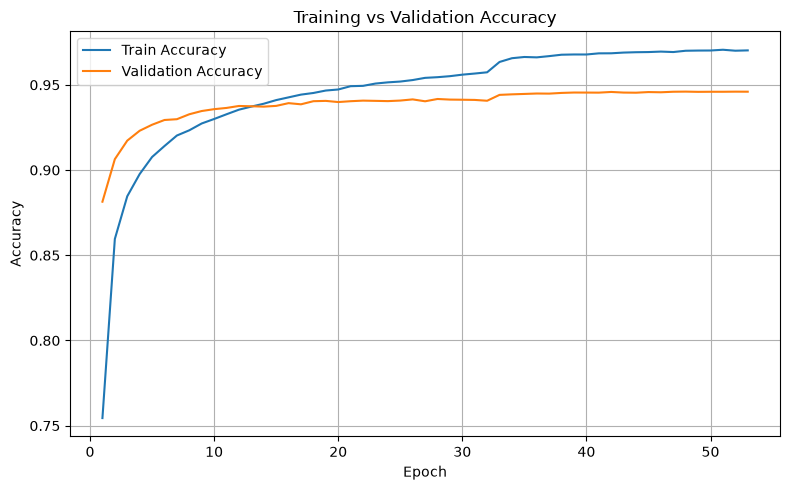

In [38]:
# Plot training and validation accuracy
if(RUN_TRAINING):
    epochs = range(1, len(train_acc_list) + 1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_acc_list, label="Train Accuracy")
    plt.plot(epochs, val_acc_list, label="Validation Accuracy")
    
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 5. Final Evaluation

Here, we load the model and used the `accuracy_at_1` function given in the project specification to evaluate the performance of the model.

In [39]:
encoder = ChessEncoder(vocab_size=VOCAB_SIZE)

encoder.load_state_dict(
    torch.load(BEST_ENCODER_PATH, map_location=DEVICE)
)

classifier = ChessClassifier(
    encoder=encoder,
    d_model=128,
    candidate_len=10
)

classifier.load_state_dict(
    torch.load(BEST_MODEL_PATH, map_location=DEVICE)
)

classifier = classifier.to(DEVICE)

In [40]:
# Given from project specification
def accuracy_at_1(y_true, probabilities):
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    assert probabilities.ndim == 2
    assert probabilities.shape[1] == 10
    assert len(y_true) == len(probabilities)

    # argmax returns classes 0,...,9, hence +1.
    y_pred = np.argmax(probabilities, axis=1) + 1

    return np.mean(y_pred == y_true)

In [44]:
# Wrapper function for final accuracy reportingdef test_classifier(model, loader, device):
def test_classifier(model, loader, device):
    model.eval()

    all_probabilities = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            logits = model(x)
            probabilities = torch.softmax(logits, dim=1)

            all_probabilities.append(probabilities.cpu().numpy())
            all_labels.append(y.numpy())

    probabilities = np.concatenate(all_probabilities, axis=0)

    # Shift label scale
    y_true = np.concatenate(all_labels, axis=0)+1

    accuracy = accuracy_at_1(
        y_true,
        probabilities
    )

    return accuracy

In [45]:
def count_trainable_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

In [46]:
print("----- Model Architecture Ratio -----")
print(summary(classifier,input_size=(64, 40),dtypes=[torch.long],))
print()

encoder_params = count_trainable_parameters(autoencoder.encoder)
reconstructor_params = count_trainable_parameters(autoencoder.reconstructor)
autoencoder_params = count_trainable_parameters(autoencoder)
classifier_head_params = count_trainable_parameters(classifier.classifier)
final_model_params = count_trainable_parameters(classifier)

print("----- Trainable Parameters -----")
print(f"Encoder:              {encoder_params:,}")
print(f"Reconstructor:        {reconstructor_params:,}")
print(f"Autoencoder:          {autoencoder_params:,}")
print(f"Classification Head:  {classifier_head_params:,}")
print(f"Final Model:          {final_model_params:,}")


test_acc = test_classifier(
    classifier,
    test_loader,
    DEVICE
)

print()
print("----- Accuracy -----")
print(f"Test Accuracy@1:      {test_acc * 100:.2f}%")

----- Model Architecture Ratio -----
Layer (type:depth-idx)                             Output Shape              Param #
ChessClassifier                                    [64, 10]                  --
├─ChessEncoder: 1-1                                [64, 40, 128]             --
│    └─Embedding: 2-1                              [64, 40, 128]             460,416
│    └─Embedding: 2-2                              [40, 128]                 5,120
│    └─TransformerEncoder: 2-3                     [64, 40, 128]             --
│    │    └─ModuleList: 3-1                        --                        397,440
├─Linear: 1-2                                      [64, 10, 1]               129
Total params: 863,105
Trainable params: 863,105
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 42.43
Input size (MB): 0.02
Forward/backward pass size (MB): 41.99
Params size (MB): 2.66
Estimated Total Size (MB): 44.67

----- Trainable Parameters -----
Encoder:              862,976
Reconstruc

## 6. Conclusion and Closing Words

#### Experimentations

| Experiment | Configuration | Accuracy |
|:---|:---|:---|
| 1. Baseline Transformer | Embedding dimension: 128 | ~91.5% |
| 2. Baseline Transformer | Embedding dimension: 256 | ~92.5% |
| 3. Pre-trained Transformer | Masking ratio: 20% | ~93.9% |
| 4. Pre-trained Transformer | Masking ratio: 30% | ~94.5% |

#### Learning Points

1. Although pre-training takes significantly longer, the improved representations learned during pre-training appear to contribute to better final model performance.
2. It is important to keep track of the training time per epoch, as training time can increase substantially if the model architecture or pre-training process is not kept in check.
3. It is important to also set a realistic hard limit to the num of epochs even with the early stopping, as seen in the pre-training with the masking ratio of 0.3, it was able to hit the hard limit of num of epochs.
4. An increased masking ratio could potentially improve the model performance but also at the cost of time to converge

#### Pain Points

1. Model training takes a long time, particularly during pre-training, even when using a reduced embedding dimension.
2. Many of the experimentation was not possible due to limited time

#### Possible Improvements

1. A larger embedding dimension appears to improve performance, as shown by the baseline Transformer, which improved from ~91.5% to ~92.5%. However, due to time constraints, I was unable to evaluate the full pre-trained architecture with the larger embedding dimension.
2. Data augmentation remains largely unexplored in this project. Exploring different augmentation techniques could potentially improve the model's generalisation capability and overall performance.
3. The increased masking ratio of 0.3 did improve the model by a noticeable amount and a further increase may improve the performance of the model further.

# Thank you for reading this project !